# 2. Simple Neural Network (NN)


---








In [1]:
import numpy as np
from sklearn.datasets import load_iris

# Data Preprocessing


In [21]:
# Loading data from sklearn
dat = load_iris()
X, y = dat.data, dat.target
y=y.reshape(-1,1)  # to prevent (n, ) dimension
no_of_Samples=X.shape[0]

# Normalization of Data
X = (X - np.mean(X, axis=0)) / np.std(X, axis=0)

# We are generating random array of number from 0 to n-1, to slice the data randomly into test train dataset
train_Data=0.80
indices=np.random.permutation(no_of_Samples)
train_indices=indices[0:int(train_Data*no_of_Samples)]
test_indices=indices[int(train_Data*no_of_Samples): ]

# test train data has been split

X_train=X[train_indices] #112, 4
X_test=X[test_indices] # 38, 4
y_train=y[train_indices] #112, 1
y_test=y[test_indices] # 38, 1

# We are initializing the params of the neural network such as weights and bias of the neurons


   We have 4 neurons in the input layer so it would make 4 connections with the neurons in the hidden layer 1 + one bias for each neuron

   And we have 3 neurons in the hiddens layer 1

   So that W1 is of matrix 3x4 <- 3 neurons and their corresponding 4 weights


   Similarly for the consecutive layers


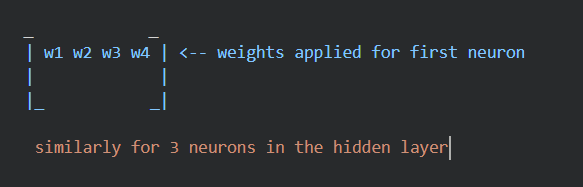

In [3]:
def initialize(sizes):
    input_layer=sizes[0]
    hidden_1 = sizes[1]
    hidden_2 = sizes[2]
    output_layer= sizes[3]

    params = {
        'W1' : np.random.randn(hidden_1, input_layer), # 3, 4
        'B1' : np.ones((hidden_1, 1)), #3, 1
        'W2' : np.random.randn(hidden_2, hidden_1), # 3, 3
        'B2' : np.ones((hidden_2,1)), #3, 1
        'W3' : np.random.randn(output_layer, hidden_2), # 3, 3
        'B3' : np.ones((output_layer,1)) # 3, 1
    }
    return params

# Sigmoid
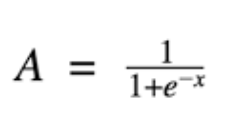

# Softmax
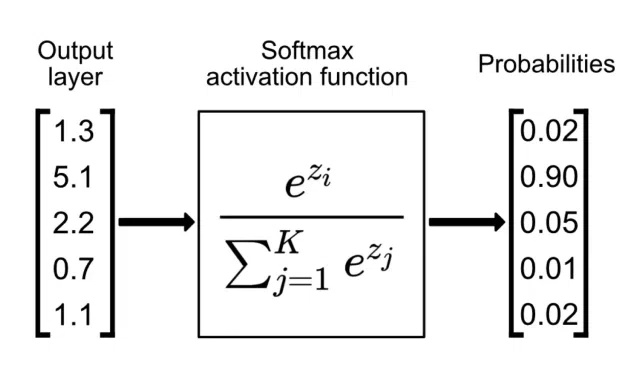



In [4]:
def sigmoid(x, derivative=False):
    x = np.clip(x, -500, 500)
    s = 1 / (1 + np.exp(-x))
    if derivative:
        return s * (1 - s)
    return s

def softmax(x):
    exps = np.exp(x - x.max())
    return exps / np.sum(exps, axis=0)

def one_hot_encoder(no_of_classes, x):
    one_Hot = np.zeros((no_of_classes, 1))
    one_Hot[x] = 1
    return one_Hot

# Forward Pass
The inputs are processed layer by layer through weights , bias and activation function to compute the final output

In [5]:
def forward_pass(X, params):
    # inputs constitute the input layer
    params['X'] = X #4 1

    params['Z1'] = np.dot(params['W1'], X) + params['B1']  # 3,4 @ 4,1 + 3, 1
    # A1 is the activation of neurons hidden layer 1
    params['A1'] = sigmoid(params['Z1']) # 3 ,1

    params['Z2'] = np.dot(params['W2'], params['A1']) + params['B2'] # 3,3 @ 3,1 + 3,1
    params['A2'] = sigmoid(params['Z2']) # 3,1

    params['Z3'] = np.dot(params['W3'], params['A2']) + params['B3'] # 3,3 @ 3,1 + 3,1
    # We apply softmax on the Z3 (logits) to convert them into the probability distribution rather then a map from 0 to 1
    params['A3'] = softmax(params['Z3']) #3, 1


    return params

# Backpropagation
We are propagating back from the output layer to input layer, calculating gradients of the loss function with respect to the weights and biases of each neuron. These gradients are then used to update the parameters using gradient descent


In [6]:
def backpropagation(params, y):
    step={}
    error = params['A3'] - y # 3,1
    step['W3'] = np.dot(error, params['A2'].T) #3,1 @ 1,3
    step['B3'] = np.sum(error, axis=1, keepdims=True) # 3,1

    # here we used the chain rule of calculus
    error = np.multiply(np.dot(params['W3'].T, error), sigmoid(params['Z2'], derivative=True))
    step['W2'] = np.dot(error, params['A1'].T)
    step['B2'] = np.sum(error, axis=1, keepdims=True)

    error = np.multiply(np.dot(params['W2'].T, error), sigmoid(params['Z1'], derivative=True))
    step['W1'] = np.dot(error, params['X'].T)
    step['B1'] = np.sum(error, axis=1, keepdims=True)

    return step

In [7]:
def gradient_step(step, params, l_r=0.01):
    for key, value in step.items():
        if key.startswith('W') or key.startswith('B'):
            params[key] -= value * l_r
    return params

In [13]:
def accuracy(predictions, y):
    # Flatten y to ensure element-wise comparison
    correct_predictions = np.sum(predictions == y.flatten())
    return correct_predictions / len(y)

In [14]:
def predict(X, params):
    # the code is identical to the forward pass
    X = X.reshape(-1,1)
    Z1 = np.dot(params['W1'], X) + params['B1'] # 3,4 @ 4 ,1
    A1 = sigmoid(Z1) # 3, 1

    Z2 = np.dot(params['W2'], A1) + params['B2'] # 3, 3 @ 3, 1
    A2 = sigmoid(Z2) # 3, 1

    Z3 = np.dot(params['W3'], A2) + params['B3'] # 3 ,3 @ 3, 1
    A3 = softmax(Z3)

    return np.argmax(A3)


# Gradient Descent  


In [ ]:
epochs=100
params = initialize([4,3,3,3])
for i in range(epochs):
    for x, y in zip(X_train, y_train):
        x = x.reshape(-1,1) # 4 1

        y_one_hot = one_hot_encoder(3, y[0]) # 3,1

        # we are forward passing to get params and then passing it into the backpropagation
        # FINALLY updating the params
        params = forward_pass(x, params)
        params = gradient_step(backpropagation(params, y_one_hot), params, 0.3)

    if i%20 == 0:
        test_predictions = []
        for x in X_test:
            x = x.reshape(-1,1)
            x_ = predict(x, params)
            test_predictions.append(x_)

        test_predictions = np.array(test_predictions)
        test_accuracy = accuracy(test_predictions, y_test)
        print(f'Epoch {i} | Accuracy {test_accuracy}')

# actually epochs of 1000 wasnt neccassary , 100 be good

Epoch 0 | Accuracy 0.7
Epoch 20 | Accuracy 1.0
Epoch 40 | Accuracy 1.0
Epoch 60 | Accuracy 1.0
Epoch 80 | Accuracy 1.0
Epoch 100 | Accuracy 0.9666666666666667
Epoch 120 | Accuracy 1.0
Epoch 140 | Accuracy 1.0
Epoch 160 | Accuracy 1.0
Epoch 180 | Accuracy 1.0
Epoch 200 | Accuracy 1.0
Epoch 220 | Accuracy 1.0
Epoch 240 | Accuracy 1.0
Epoch 260 | Accuracy 1.0
Epoch 280 | Accuracy 1.0
Epoch 300 | Accuracy 1.0
Epoch 320 | Accuracy 1.0
Epoch 340 | Accuracy 1.0
Epoch 360 | Accuracy 1.0
Epoch 380 | Accuracy 1.0
Epoch 400 | Accuracy 1.0
Epoch 420 | Accuracy 1.0
Epoch 440 | Accuracy 1.0
Epoch 460 | Accuracy 1.0
Epoch 480 | Accuracy 1.0
Epoch 500 | Accuracy 1.0
Epoch 520 | Accuracy 1.0
Epoch 540 | Accuracy 1.0
Epoch 560 | Accuracy 1.0
Epoch 580 | Accuracy 1.0
Epoch 600 | Accuracy 1.0
Epoch 620 | Accuracy 1.0
Epoch 640 | Accuracy 1.0
Epoch 660 | Accuracy 1.0
Epoch 680 | Accuracy 1.0
Epoch 700 | Accuracy 1.0
Epoch 720 | Accuracy 1.0
Epoch 740 | Accuracy 1.0
Epoch 760 | Accuracy 1.0
Epoch 780 | Accu

In [24]:
print(y_test[4])
print(predict(X_test[4], params))

[0]
0
